<a href="https://colab.research.google.com/github/jayantjai/Python-Learning-EDA-Project-/blob/main/SuperStore_DataSet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Day 1

In [2]:
import pandas as pd

Importing the complete datashet in the excel format

In [3]:

from google.colab import files

uploaded = files.upload()

Saving Bank_Churn_Messy.xlsx to Bank_Churn_Messy.xlsx


In [4]:
import pandas as pd
excel_file = "/content/Bank_Churn_Messy.xlsx"
xls = pd.ExcelFile(excel_file)
print(xls.sheet_names)

['Customer_Info', 'Account_Info']


In [5]:
customer = pd.read_excel("/content/Bank_Churn_Messy.xlsx",sheet_name = "Customer_Info")

In [80]:
account = pd.read_excel("/content/Bank_Churn_Messy.xlsx",sheet_name = "Account_Info")

In [7]:
customer

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88
1,15647311,Hill,608,Spain,Female,41.0,1,€112542.58
2,15619304,Onio,502,French,Female,42.0,8,€113931.57
3,15701354,Boni,699,FRA,Female,39.0,1,€93826.63
4,15737888,Mitchell,850,Spain,Female,43.0,2,€79084.1
...,...,...,...,...,...,...,...,...
9996,15569892,Johnstone,516,French,Male,35.0,10,€101699.77
9997,15584532,Liu,709,FRA,Female,36.0,7,€42085.58
9998,15682355,Sabbatini,772,Germany,Male,42.0,3,€92888.52
9999,15628319,Walker,792,French,Female,28.0,4,€38190.78


1. Checking Data set for EDA

In [8]:
customer.describe()

,CustomerId,CreditScore,Age,Tenure
count,1.000100e+04,10001.000000,9998.000000,10001.000000
mean,1.569093e+07,650.542946,38.920984,5.012699
std,7.193531e+04,96.658818,10.489116,2.892047
min,1.556570e+07,350.000000,18.000000,0.000000
25%,1.562852e+07,584.000000,32.000000,3.000000
50%,1.569073e+07,652.000000,37.000000,5.000000
75%,1.575323e+07,718.000000,44.000000,7.000000
max,1.581569e+07,850.000000,92.000000,10.000000


Checking datatypes of all the columns

In [9]:
customer.dtypes

,0
CustomerId,int64
Surname,object
CreditScore,int64
Geography,object
Gender,object
Age,float64
Tenure,int64
EstimatedSalary,object


Converting the existed datatypes into correct datatypes

In [10]:
customer['EstimatedSalary'] = customer['EstimatedSalary'].str.replace('€','').astype(float)

New data type of "EstimatedSalary" column

In [11]:
customer

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
0,15634602,Hargrave,619,FRA,Female,42.0,2,101348.88
1,15647311,Hill,608,Spain,Female,41.0,1,112542.58
2,15619304,Onio,502,French,Female,42.0,8,113931.57
3,15701354,Boni,699,FRA,Female,39.0,1,93826.63
4,15737888,Mitchell,850,Spain,Female,43.0,2,79084.10
...,...,...,...,...,...,...,...,...
9996,15569892,Johnstone,516,French,Male,35.0,10,101699.77
9997,15584532,Liu,709,FRA,Female,36.0,7,42085.58
9998,15682355,Sabbatini,772,Germany,Male,42.0,3,92888.52
9999,15628319,Walker,792,French,Female,28.0,4,38190.78


In [12]:
customer.dtypes

,0
CustomerId,int64
Surname,object
CreditScore,int64
Geography,object
Gender,object
Age,float64
Tenure,int64
EstimatedSalary,float64


In [13]:
customer = customer.copy()

Replacing "FRA" and "French" with "France"

In [14]:
customer['Geography'] = customer['Geography'].str.replace('FRA','France',regex=False)
customer['Geography'] = customer['Geography'].str.replace('French','France',regex=False)

In [15]:
customer.describe()

,CustomerId,CreditScore,Age,Tenure,EstimatedSalary
count,1.000100e+04,10001.000000,9998.000000,10001.000000,10001.000000
mean,1.569093e+07,650.542946,38.920984,5.012699,99756.038763
std,7.193531e+04,96.658818,10.489116,2.892047,60583.962827
min,1.556570e+07,350.000000,18.000000,0.000000,-999999.000000
25%,1.562852e+07,584.000000,32.000000,3.000000,50908.480000
50%,1.569073e+07,652.000000,37.000000,5.000000,100183.050000
75%,1.575323e+07,718.000000,44.000000,7.000000,149384.430000
max,1.581569e+07,850.000000,92.000000,10.000000,199992.480000


Identification of duplicates.
How many times each unique value appears

In [16]:
customer.value_counts()

,,,,,,,,count
CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,
15628319,Walker,792,France,Female,28.0,4,38190.78,2
15732113,Butters,671,Spain,Male,50.0,8,2560.11,1
15732175,Bruno,776,France,Male,37.0,2,8065.00,1
15732199,Gether,837,Spain,Male,31.0,9,50972.60,1
15732202,Abramovich,615,France,Male,34.0,1,73124.53,1
...,...,...,...,...,...,...,...,...
15649379,Somayina,850,France,Female,46.0,3,187980.21,1
15649414,Walker,570,France,Female,61.0,6,45214.04,1
15649418,Krylov,776,France,Female,29.0,7,115818.51,1


Removing duplicates

In [17]:
customer.drop_duplicates()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
0,15634602,Hargrave,619,France,Female,42.0,2,101348.88
1,15647311,Hill,608,Spain,Female,41.0,1,112542.58
2,15619304,Onio,502,France,Female,42.0,8,113931.57
3,15701354,Boni,699,France,Female,39.0,1,93826.63
4,15737888,Mitchell,850,Spain,Female,43.0,2,79084.10
...,...,...,...,...,...,...,...,...
9995,15606229,Obijiaku,771,France,Male,39.0,5,96270.64
9996,15569892,Johnstone,516,France,Male,35.0,10,101699.77
9997,15584532,Liu,709,France,Female,36.0,7,42085.58
9998,15682355,Sabbatini,772,Germany,Male,42.0,3,92888.52


Checking Null values

In [18]:
customer.isnull().sum()

,0
CustomerId,0
Surname,3
CreditScore,0
Geography,0
Gender,0
Age,3
Tenure,0
EstimatedSalary,0


Droping Null Values

In [19]:
customer.dropna()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
0,15634602,Hargrave,619,France,Female,42.0,2,101348.88
1,15647311,Hill,608,Spain,Female,41.0,1,112542.58
2,15619304,Onio,502,France,Female,42.0,8,113931.57
3,15701354,Boni,699,France,Female,39.0,1,93826.63
4,15737888,Mitchell,850,Spain,Female,43.0,2,79084.10
...,...,...,...,...,...,...,...,...
9996,15569892,Johnstone,516,France,Male,35.0,10,101699.77
9997,15584532,Liu,709,France,Female,36.0,7,42085.58
9998,15682355,Sabbatini,772,Germany,Male,42.0,3,92888.52
9999,15628319,Walker,792,France,Female,28.0,4,38190.78


In [20]:
customer.isnull().sum()

,0
CustomerId,0
Surname,3
CreditScore,0
Geography,0
Gender,0
Age,3
Tenure,0
EstimatedSalary,0


In [21]:
customer

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
0,15634602,Hargrave,619,France,Female,42.0,2,101348.88
1,15647311,Hill,608,Spain,Female,41.0,1,112542.58
2,15619304,Onio,502,France,Female,42.0,8,113931.57
3,15701354,Boni,699,France,Female,39.0,1,93826.63
4,15737888,Mitchell,850,Spain,Female,43.0,2,79084.10
...,...,...,...,...,...,...,...,...
9996,15569892,Johnstone,516,France,Male,35.0,10,101699.77
9997,15584532,Liu,709,France,Female,36.0,7,42085.58
9998,15682355,Sabbatini,772,Germany,Male,42.0,3,92888.52
9999,15628319,Walker,792,France,Female,28.0,4,38190.78


Avg Salary and Credit score (Gender Based)

In [22]:
customer.groupby('Gender')[['EstimatedSalary','CreditScore']].mean().round(2)

,EstimatedSalary,CreditScore
Gender,,
Female,100107.98,650.86
Male,99462.98,650.28


Avg Salary and Credit score (Region Based)

In [23]:
customer.groupby('Geography')[['EstimatedSalary', 'CreditScore']].mean().round(2)

,EstimatedSalary,CreditScore
Geography,,
France,99671.50,649.70
Germany,100674.94,651.45
Spain,98996.43,651.33


Avg Salary and Credit Score of each gender in every region

In [24]:
customer.groupby(['Geography', 'Gender'])[['EstimatedSalary','CreditScore']].agg(['mean','median']).round(2)

EstimatedSalary            CreditScore       
                            mean     median        mean median
Geography Gender                                              
France    Female        99059.61   99377.64      649.25  652.0
          Male         100174.25   99017.34      650.06  653.0
Germany   Female       101524.22  104617.99      653.09  651.0
          Male          99905.03   97892.70      649.97  650.5
Spain     Female       100734.11  102889.34      651.77  653.0
          Male          97633.09   95593.92      650.99  650.0

2. Check distributions and outliers

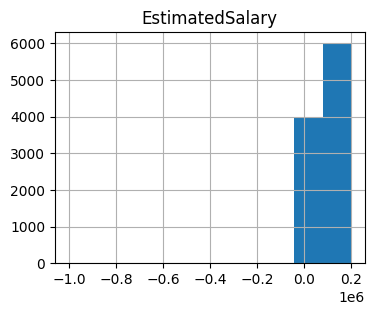

count     10001.000000
mean      99756.038763
std       60583.962827
min     -999999.000000
25%       50908.480000
50%      100183.050000
75%      149384.430000
max      199992.480000
Name: EstimatedSalary, dtype: float64


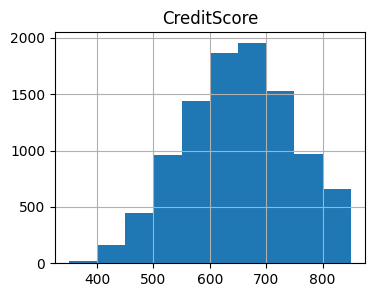

count    10001.000000
mean       650.542946
std         96.658818
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: CreditScore, dtype: float64


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
list = ['EstimatedSalary','CreditScore']
for i in list:
  plt.figure(figsize=(4,3))
  customer[i].hist()
  plt.title(i)
  plt.show()
  print(customer[i].describe())


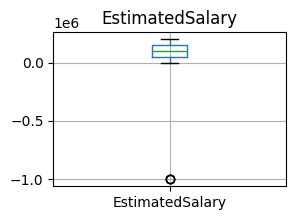

count     10001.000000
mean      99756.038763
std       60583.962827
min     -999999.000000
25%       50908.480000
50%      100183.050000
75%      149384.430000
max      199992.480000
Name: EstimatedSalary, dtype: float64


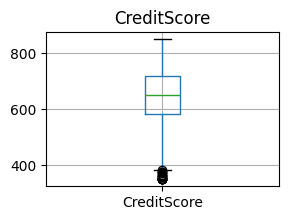

count    10001.000000
mean       650.542946
std         96.658818
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: CreditScore, dtype: float64


In [27]:

list = ['EstimatedSalary','CreditScore']
for i in list:
  plt.figure(figsize= (3,2))
  customer.boxplot(column =i)
  plt.title(i)
  plt.show()
  print(customer[i].describe())

In [81]:
account

,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited
0,15634602,€0.0,1,Yes,2,Yes,1
1,15634602,€0.0,1,Yes,2,Yes,1
2,15647311,€83807.86,1,Yes,1,Yes,0
3,15619304,€159660.8,3,No,8,No,1
4,15701354,€0.0,2,No,1,No,0
...,...,...,...,...,...,...,...
9997,15569892,€57369.61,1,Yes,10,Yes,0
9998,15584532,€0.0,1,Yes,7,Yes,1
9999,15682355,€75075.31,2,No,3,No,1
10000,15628319,€130142.79,1,No,4,No,0


In [82]:
account.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10002 entries, 0 to 10001
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   CustomerId      10002 non-null  int64 
 1   Balance         10002 non-null  object
 2   NumOfProducts   10002 non-null  int64 
 3   HasCrCard       10002 non-null  object
 4   Tenure          10002 non-null  int64 
 5   IsActiveMember  10002 non-null  object
 6   Exited          10002 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 547.1+ KB


In [83]:
account.describe()

,CustomerId,NumOfProducts,Tenure,Exited
count,1.000200e+04,10002.000000,10002.000000,10002.000000
mean,1.569093e+07,1.530094,5.012398,0.203759
std,7.193392e+04,0.581645,2.892060,0.402812
min,1.556570e+07,1.000000,0.000000,0.000000
25%,1.562852e+07,1.000000,3.000000,0.000000
50%,1.569073e+07,1.000000,5.000000,0.000000
75%,1.575323e+07,2.000000,7.000000,0.000000
max,1.581569e+07,4.000000,10.000000,1.000000


In [84]:
account.dtypes

,0
CustomerId,int64
Balance,object
NumOfProducts,int64
HasCrCard,object
Tenure,int64
IsActiveMember,object
Exited,int64


Changing Datatypes of Columns

In [85]:
account['Balance'] = (
    account['Balance']
    .str.replace('€', '', regex=False)
    .str.strip()
    .astype(float)
)

In [86]:
account.head()

,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited
0,15634602,0.00,1,Yes,2,Yes,1
1,15634602,0.00,1,Yes,2,Yes,1
2,15647311,83807.86,1,Yes,1,Yes,0
3,15619304,159660.80,3,No,8,No,1
4,15701354,0.00,2,No,1,No,0


Again Checking the Datatypes

In [87]:
account.dtypes

,0
CustomerId,int64
Balance,float64
NumOfProducts,int64
HasCrCard,object
Tenure,int64
IsActiveMember,object
Exited,int64


Finding Null and Duplicate Values

In [88]:
account.value_counts().head()

,,,,,,,count
CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited,
15634602,0.00,1,Yes,2,Yes,1,2
15628319,130142.79,1,No,4,No,0,2
15732102,150905.03,2,No,3,No,0,1
15732175,0.00,1,Yes,2,Yes,0,1
15732199,104678.62,1,Yes,9,Yes,0,1


In [89]:
account.drop_duplicates().head()

,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited
0,15634602,0.00,1,Yes,2,Yes,1
2,15647311,83807.86,1,Yes,1,Yes,0
3,15619304,159660.80,3,No,8,No,1
4,15701354,0.00,2,No,1,No,0
5,15737888,125510.82,1,Yes,2,Yes,0


In [90]:
account.isnull().sum()

,0
CustomerId,0
Balance,0
NumOfProducts,0
HasCrCard,0
Tenure,0
IsActiveMember,0
Exited,0


There are no null values in the columns of 'account' dataset

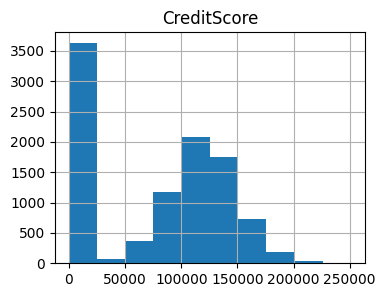

count     10002.000000
mean      76483.606846
std       62398.160146
min           0.000000
25%           0.000000
50%       97198.540000
75%      127647.840000
max      250898.090000
Name: Balance, dtype: float64


In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(4,3))
account['Balance'].hist()
plt.title(i)
plt.show()
print(account['Balance'].describe())


In [92]:
(account['Balance']==0).sum()

np.int64(3618)

So, there are total 3618 Customers who are having 0 euros as their balance.

Now, we will perform the "Joining" operations on these to tables

In [94]:
superstore = pd.merge(customer,account, on = 'CustomerId')

In [95]:
superstore.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure_x,EstimatedSalary,Balance,NumOfProducts,HasCrCard,Tenure_y,IsActiveMember,Exited
0,15634602,Hargrave,619,France,Female,42.0,2,101348.88,0.00,1,Yes,2,Yes,1
1,15634602,Hargrave,619,France,Female,42.0,2,101348.88,0.00,1,Yes,2,Yes,1
2,15647311,Hill,608,Spain,Female,41.0,1,112542.58,83807.86,1,Yes,1,Yes,0
3,15619304,Onio,502,France,Female,42.0,8,113931.57,159660.80,3,No,8,No,1
4,15701354,Boni,699,France,Female,39.0,1,93826.63,0.00,2,No,1,No,0
